## 垂直整合 benchmark， benchmark方法有 RunscArches， RunMultigrate， RunTotalVI 和 RunSeurat V4
## 数据集 RNA+ADT

## Garfield method

用于水平整合的数据集 3_GSE150599 4_GSE194122 

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import os
import time

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from scipy.sparse import csr_matrix
from scipy import io
from tqdm import tqdm


def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")


def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna


def read_adt_data(adt_dir):
    """Read ADT data from the specified CSV file and return it as an AnnData object."""
    adata_ADT = pd.read_csv(f'{adt_dir}/ADT.csv', index_col=0)
    adata_ADT.columns = adata_ADT.columns.str.replace('.', '-')
    # adata_ADT.index = adata_ADT.index.str.replace('.', '_')
    # adata_ADT.index = adata_ADT.index.str.replace('-', '_')
    adata_ADT = ad.AnnData(adata_ADT.T)
    adata_ADT.X = adata_ADT.X.astype(np.float64)
    # numpy 转为 sparse matrix
    adata_ADT.X = csr_matrix(adata_ADT.X)
    adata_ADT.layers["counts"] = adata_ADT.X.copy()
    return adata_ADT

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)


def read_multiomics_data(rna_dir, adt_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(adt_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        adt = read_adt_data(adt_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    # adt.obs = adt.obs.join(metadata, how="left")

    return {"rna": rna, "adt": adt}

### 数据集 2_GSE128639

In [2]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [3]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [4]:
# 定义路径
dataset = '2_GSE128639'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/RNA'
adt_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/metadata.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'

# 判断结果目录是否存在，不存在则创建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# 读取数据
data = read_multiomics_data(rna_dir, adt_dir, metadata_file)

# 访问 RNA 和 ADT 数据
adata_RNA = data["rna"]
adata_ADT = data["adt"]
adata_RNA.var_names_make_unique()
adata_ADT.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ADT.layers['counts'] = adata_ADT.X.copy()

mdata = MuData({"rna": adata_RNA, "adt": adata_ADT})
mdata

Reading multiomics data: 100%|██████████| 3/3 [00:02<00:00,  1.43it/s]


MuData object with n_obs × n_vars = 30672 × 17034
  2 modalities
    rna:	30672 x 17009
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'lane', 'donor', 'celltype.l1', 'celltype.l2', 'RNA.weight'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	30672 x 25
      layers:	'counts'

In [7]:
adata_RNA.obs['donor'].value_counts()

donor
batch2    16204
batch1    14468
Name: count, dtype: int64

In [5]:
adata_RNA.obs['celltype.l1'].value_counts()

celltype.l1
T cell              14901
Mono/DC              7729
B cell               3753
Progenitor cells     2879
NK                   1410
Name: count, dtype: int64

In [6]:
adata_RNA.obs['celltype.l2'].value_counts()

celltype.l2
CD14 Mono         6486
CD4 Naive         4500
CD8 Naive         3974
CD4 Memory        3360
Naive B           1900
Memory B          1630
NK                1267
Prog_RBC           915
GMP                748
CD8 Effector_1     577
CD8 Memory_2       555
MAIT               520
cDC2               482
CD8 Memory_1       444
CD16 Mono          433
gdT                367
pDC                328
CD8 Effector_2     307
Treg               297
LMPP               292
HSC                263
Prog_DC            263
Plasmablast        223
Prog_B 1           145
CD56 bright NK     143
Prog_B 2           129
Prog_Mk            124
Name: count, dtype: int64

In [8]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=None,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/2_GSE128639


In [9]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 18 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 6 batches, average batch size is 5112, and max batch size is 5112.
The second data is split into 6 batches, average batch size is 5112, and max batch size is 5112.
Batch to batch correspondence is:
  ['0<->0', '1<->1', '2<->2', '3<->3', '4<->4', '5<->5'].
Now at batch 0<->0...
Now at batch 1<->1...
Now at batch 2<->2...
Now at batch 3<->3...
Now at batch 4<->4...
Now at batch 5<->5...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Now at batch 1<->1...
Now at batch 2<->2...
Now at batch 3<->3...
Now at batch 4<->4...
Now at batch 5<->5...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
21468/30672 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating match

In [10]:
# Train model  
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 27605
Number of validation nodes: 3067
Number of training edges: 331530
Number of validation edges: 36836
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7471; val_auprc_score: 0.7751; val_best_acc_score: 0.7147; val_best_f1_score: 0.6922; train_kl_reg_loss: 139.5388; train_edge_recon_loss: 108423.4753; train_gene_expr_recon_loss: 471983.4946; train_lambda_latent_adj_recon_loss: 3141.4131; train_lambda_latent_contrastive_instanceloss: 6.8376; train_lambda_latent_contrastive_clusterloss: 3.3775; train_global_loss: 583698.1370; train_optim_loss: 583698.1370; val_kl_reg_loss: 228.5583; val_edge_recon_loss: 106031.2300; val_gene_expr_recon_loss: 298544.2569; val_lambda_latent_adj_recon_loss: 4008.3192; val_lambda_latent_contrastive_instanceloss: 6.5417; val_lambda_latent_contrastive_clusterloss: 2.9962; val_global_loss: 408821.8958; val_optim_lo

In [11]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

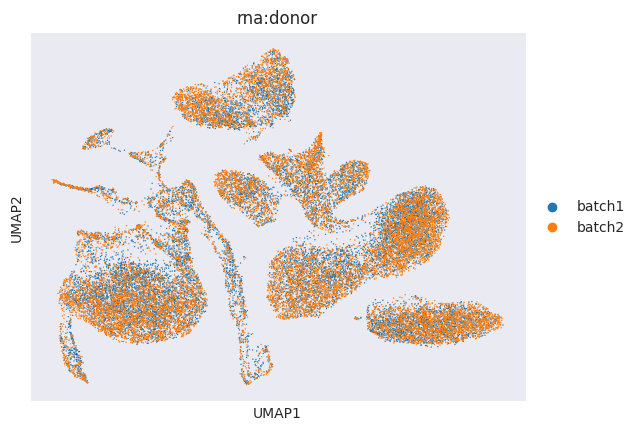

In [15]:
sc.pl.umap(model.adata, color=['rna:donor'], wspace=0.15, show=True)

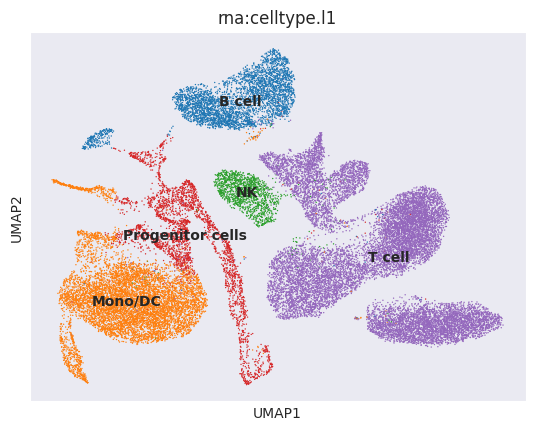

In [12]:
sc.pl.umap(model.adata, color=['rna:celltype.l1'], wspace=0.15, show=True, legend_loc='on data')

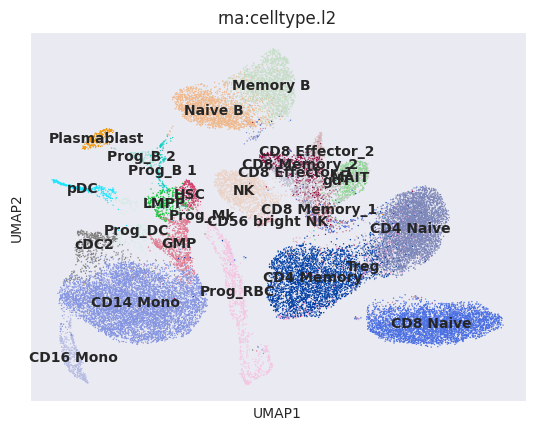

In [13]:
sc.pl.umap(model.adata, color=['rna:celltype.l2'], wspace=0.15, show=True, legend_loc='on data')

In [16]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

25

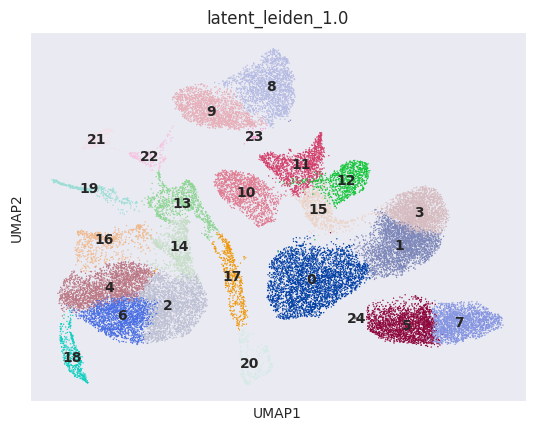

In [17]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [18]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/2_GSE128639/model/attr.pkl


In [19]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 7_zenodo6368128/LUNG

In [60]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [61]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [62]:
# 定义路径
dataset = '7_zenodo6368128/LUNG'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/RNA'
adt_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/metadata.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'

# 判断结果目录是否存在，不存在则创建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# 读取数据
data = read_multiomics_data(rna_dir, adt_dir, metadata_file)

# 访问 RNA 和 ADT 数据
adata_RNA = data["rna"]
adata_ADT = data["adt"]
adata_RNA.var_names_make_unique()
adata_ADT.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ADT.layers['counts'] = adata_ADT.X.copy()

mdata = MuData({"rna": adata_RNA, "adt": adata_ADT})
mdata

Reading multiomics data: 100%|██████████| 3/3 [00:00<00:00, 12.47it/s]


MuData object with n_obs × n_vars = 3362 × 33566
  2 modalities
    rna:	3362 x 33514
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	3362 x 52
      layers:	'counts'

In [63]:
adata_RNA.obs['tissue'].value_counts()

tissue
Lung    3362
Name: count, dtype: int64

In [64]:
adata_RNA.obs['group'].value_counts()

group
Lung_50ul_1_500k    1681
Lung_50ul_4_500k    1681
Name: count, dtype: int64

In [65]:
adata_RNA.obs['celltype'].value_counts()

celltype
T.CD.EM       824
T.CD8.CM      614
B.Plasma.1    518
Macro         260
T.CD8.EM      228
B.Lung        206
T.Treg        174
T.Prolif      132
T.CD4         110
Fibro         108
T.CD8          62
mDC.Lung       50
B.Plasma.2     44
Epithelia      32
Name: count, dtype: int64

In [66]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=None,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/7_zenodo6368128/LUNG


In [67]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 8 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
2353/3362 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
2018/2018 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [68]:
# Train model  
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 3026
Number of validation nodes: 336
Number of training edges: 23086
Number of validation edges: 2565
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7855; val_auprc_score: 0.7941; val_best_acc_score: 0.7086; val_best_f1_score: 0.7266; train_kl_reg_loss: 15696.5710; train_edge_recon_loss: 107338.7812; train_gene_expr_recon_loss: 3468155925.8385; train_lambda_latent_adj_recon_loss: 1019.6721; train_lambda_latent_contrastive_instanceloss: 7.1642; train_lambda_latent_contrastive_clusterloss: 3.7562; train_global_loss: 3468280203.9896; train_optim_loss: 3468280203.9896; val_kl_reg_loss: 17.8702; val_edge_recon_loss: 71568.5938; val_gene_expr_recon_loss: 508953.9375; val_lambda_latent_adj_recon_loss: 615.2789; val_lambda_latent_contrastive_instanceloss: 6.9379; val_lambda_latent_contrastive_clusterloss: 3.7496; val_global_loss: 581166.3125; val_o

In [69]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

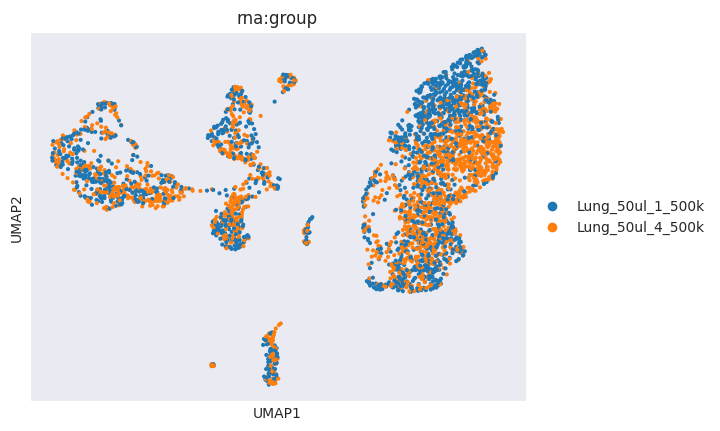

In [70]:
sc.pl.umap(model.adata, color=['rna:group'], wspace=0.15, show=True)

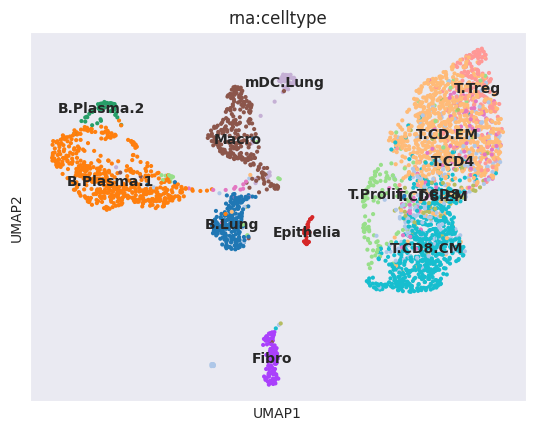

In [71]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [72]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

20

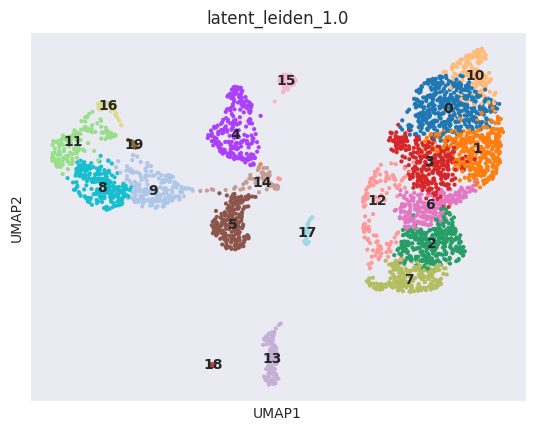

In [73]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [74]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/7_zenodo6368128/LUNG/model/attr.pkl


In [75]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 7_zenodo6368128/PBMC

In [37]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [38]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [46]:
# 定义路径
dataset = '7_zenodo6368128/PBMC'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/RNA'
adt_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/metadata.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'

# 判断结果目录是否存在，不存在则创建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# 读取数据
data = read_multiomics_data(rna_dir, adt_dir, metadata_file)

# 访问 RNA 和 ADT 数据
adata_RNA = data["rna"]
adata_ADT = data["adt"]
adata_RNA.var_names_make_unique()
adata_ADT.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ADT.layers['counts'] = adata_ADT.X.copy()

mdata = MuData({"rna": adata_RNA, "adt": adata_ADT})
mdata

Reading multiomics data: 100%|██████████| 3/3 [00:00<00:00,  8.31it/s]


MuData object with n_obs × n_vars = 7108 × 33566
  2 modalities
    rna:	7108 x 33514
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT', 'RNA.weight', 'ADT.weight', 'wsnn_res.2', 'seurat_clusters'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	7108 x 52
      layers:	'counts'

In [47]:
adata_RNA.obs['tissue'].value_counts()

tissue
PBMC    7108
Name: count, dtype: int64

In [48]:
adata_RNA.obs['group'].value_counts()

group
PBMC_25ul_4_1000k    1777
PBMC_25ul_4_200k     1777
PBMC_50ul_1_1000k    1777
PBMC_50ul_4_1000k    1777
Name: count, dtype: int64

In [49]:
adata_RNA.obs['celltype'].value_counts()

celltype
T.CD4        2448
Mono.1       1276
T.CD8         952
Mono.2        640
B.Blood       524
Mono.3        476
NK            300
Mono.Int      176
mDC.Blood     148
T.CD.EM        92
pDC            76
Name: count, dtype: int64

In [50]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=None,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/7_zenodo6368128/PBMC


In [51]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 14 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
4975/7108 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
4266/4266 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [52]:
# Train model  
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 6397
Number of validation nodes: 711
Number of training edges: 49785
Number of validation edges: 5531
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8404; val_auprc_score: 0.8035; val_best_acc_score: 0.7798; val_best_f1_score: 0.8004; train_kl_reg_loss: 29.6466; train_edge_recon_loss: 102680.3980; train_gene_expr_recon_loss: 335918.7236; train_lambda_latent_adj_recon_loss: 1490.7924; train_lambda_latent_contrastive_instanceloss: 7.1065; train_lambda_latent_contrastive_clusterloss: 3.7070; train_global_loss: 440130.3702; train_optim_loss: 440130.3702; val_kl_reg_loss: 38.4550; val_edge_recon_loss: 69205.2676; val_gene_expr_recon_loss: 308279.7188; val_lambda_latent_adj_recon_loss: 1986.0668; val_lambda_latent_contrastive_instanceloss: 6.7666; val_lambda_latent_contrastive_clusterloss: 3.5789; val_global_loss: 379519.8750; val_optim_loss: 379

In [53]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

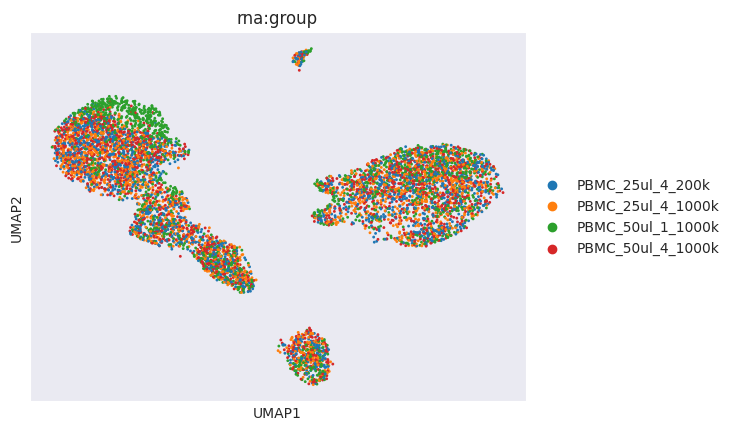

In [54]:
sc.pl.umap(model.adata, color=['rna:group'], wspace=0.15, show=True)

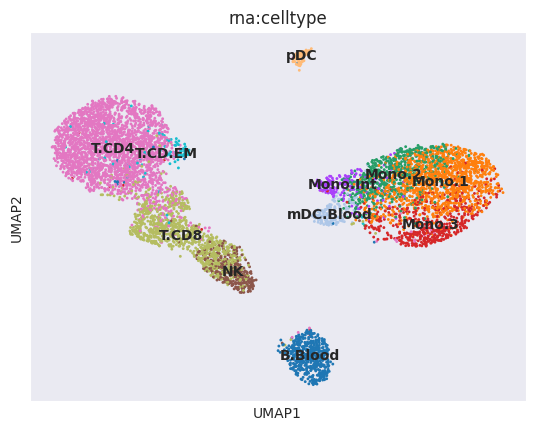

In [55]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [56]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

14

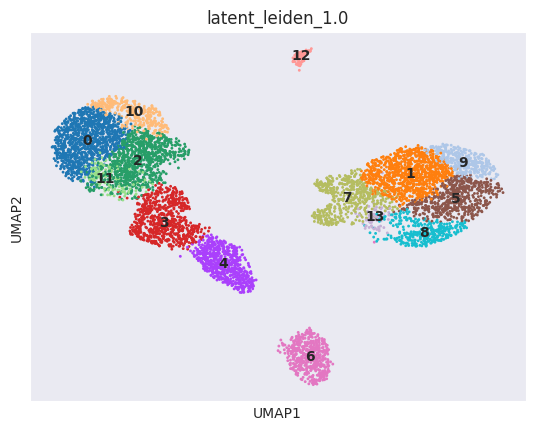

In [57]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [58]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/7_zenodo6368128/PBMC/model/attr.pkl


In [59]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 12_GSE193181/P5

In [2]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [3]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [4]:
# 定义路径
dataset = '12_GSE193181/P5'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/RNA'
adt_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/metadata.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'

# 判断结果目录是否存在，不存在则创建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# 读取数据
data = read_multiomics_data(rna_dir, adt_dir, metadata_file)

# 访问 RNA 和 ADT 数据
adata_RNA = data["rna"]
adata_ADT = data["adt"]
adata_RNA.var_names_make_unique()
adata_ADT.var_names_make_unique()
# Remove '-Ab' suffix from adata_ADT.var_names
adata_ADT.var_names = adata_ADT.var_names.str.replace('-Ab', '', regex=False)
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ADT.layers['counts'] = adata_ADT.X.copy()

mdata = MuData({"rna": adata_RNA, "adt": adata_ADT})
mdata

Reading multiomics data: 100%|██████████| 3/3 [00:10<00:00,  3.36s/it]


MuData object with n_obs × n_vars = 78530 × 26099
  2 modalities
    rna:	78530 x 26078
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'sample.effect', 'sample', 'twin', 'sort', 'nCount_Ab', 'nFeature_Ab', 'TCR_frequency', 'diagnosis', 'twin_pair', 'ct_highres', 'expand', 'CD25_expression'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	78530 x 21
      layers:	'counts'

In [5]:
adata_ADT.var_names

Index(['VLA4', 'CD8a', 'CD16', 'CD25', 'CD27', 'CD38', 'TCRgd', 'CD45RA',
       'CD45RO', 'CD127', 'CD86', 'CCR7', 'CD56', 'HLA-DR', 'CD14', 'CD11b',
       'CD20', 'CD161', 'mIgG1-control', 'mIgG2a-control', 'mIgG2b-control'],
      dtype='object')

In [6]:
adata_RNA.obs['sample'].value_counts()

sample
X84_P5     7328
X353_P5    7325
X327_P5    6556
X352_P5    6252
X351_P5    6044
X324_P5    5190
X323_P5    5185
X354_P5    5111
X328_P5    4965
X343_P5    4458
X157_P5    3899
X344_P5    3261
X166_P5    3155
X182_P5    3140
X158_P5    2656
X165_P5    2254
X140_P5    1445
X139        306
Name: count, dtype: int64

In [7]:
adata_RNA.obs['ct_highres'].value_counts()

ct_highres
TCM_3       15955
Tna_1       11181
TCM_1        7224
TCM_5        6409
Tna_5        5797
Tna_2        5718
Tna_4        5546
Tna_3        5294
TCM_4        5096
TCM_2        2675
Tna_6        2215
Treg         2137
IFN_sign     1530
TEM_1         956
TEM_2         797
Name: count, dtype: int64

In [8]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=None,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=50., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/12_GSE193181/P5


In [9]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 13 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 15 batches, average batch size is 5235, and max batch size is 5240.
The second data is split into 15 batches, average batch size is 5235, and max batch size is 5240.
Batch to batch correspondence is:
  ['0<->0', '1<->1', '2<->2', '3<->3', '4<->4', '5<->5', '6<->6', '7<->7', '8<->8', '9<->9', '10<->10', '11<->11', '12<->12', '13<->13', '14<->14'].
Now at batch 0<->0...
Now at batch 1<->1...
Now at batch 2<->2...
Now at batch 3<->3...
Now at batch 4<->4...
Now at batch 5<->5...
Now at batch 6<->6...
Now at batch 7<->7...
Now at batch 8<->8...
Now at batch 9<->9...
Now at batch 10<->10...
Now at batch 11<->11...
Now at batch 12<->12...
Now at batch 13<->13...
Now at batch 14<->14...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Now at batch 1<->1...


In [10]:
# Train model  
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 70677
Number of validation nodes: 7853
Number of training edges: 1487032
Number of validation edges: 165225
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.6743; val_auprc_score: 0.6957; val_best_acc_score: 0.6126; val_best_f1_score: 0.6828; train_kl_reg_loss: 253.3437; train_edge_recon_loss: 110549.6526; train_gene_expr_recon_loss: 287956.3180; train_lambda_latent_adj_recon_loss: 4445.3459; train_lambda_latent_contrastive_instanceloss: 6.5945; train_lambda_latent_contrastive_clusterloss: 2.9842; train_global_loss: 403214.2381; train_optim_loss: 403214.2381; val_kl_reg_loss: 297.4062; val_edge_recon_loss: 107221.0538; val_gene_expr_recon_loss: 205811.2496; val_lambda_latent_adj_recon_loss: 5061.9902; val_lambda_latent_contrastive_instanceloss: 6.4231; val_lambda_latent_contrastive_clusterloss: 2.4781; val_global_loss: 318400.6006; val_optim_

In [11]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

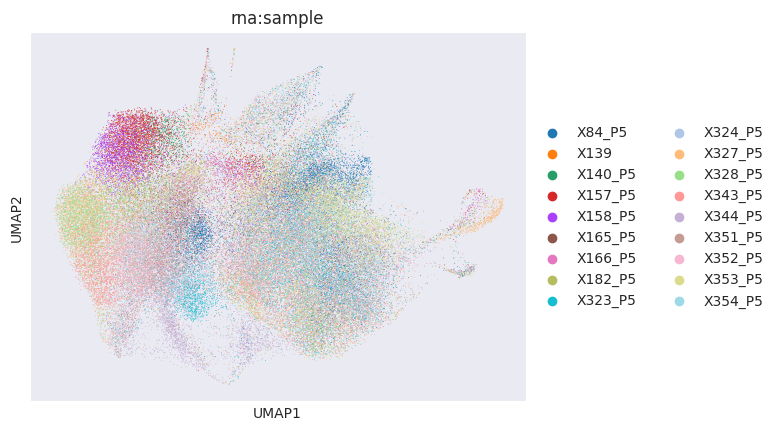

In [12]:
sc.pl.umap(model.adata, color=['rna:sample'], wspace=0.15, show=True)

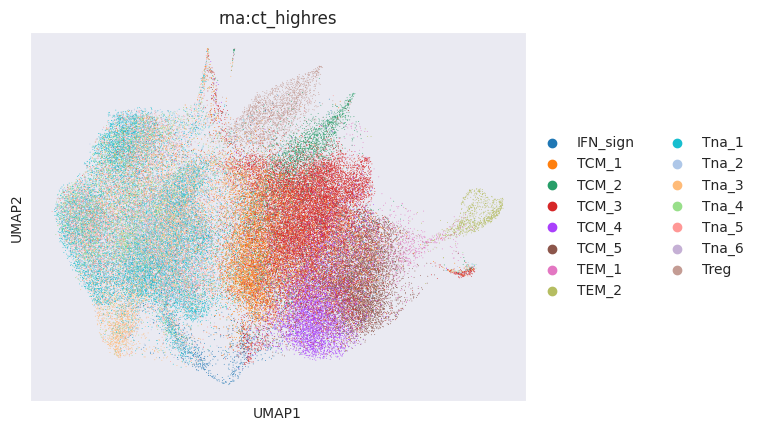

In [13]:
sc.pl.umap(model.adata, color=['rna:ct_highres'], wspace=0.15, show=True)

In [16]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

25

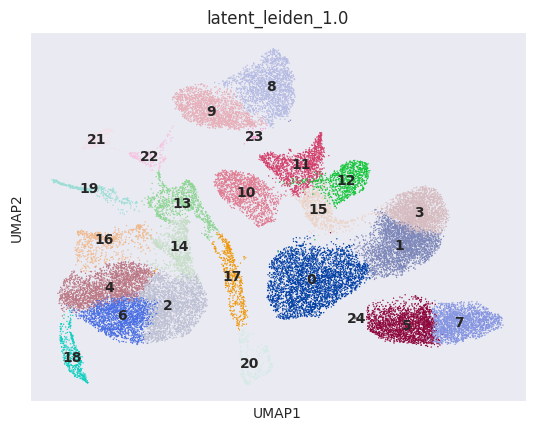

In [17]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [18]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/2_GSE128639/model/attr.pkl


In [19]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 12_GSE193181/P8

In [20]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [21]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [22]:
# 定义路径
dataset = '12_GSE193181/P8'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/RNA'
adt_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/{dataset}/metadata.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'

# 判断结果目录是否存在，不存在则创建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# 读取数据
data = read_multiomics_data(rna_dir, adt_dir, metadata_file)

# 访问 RNA 和 ADT 数据
adata_RNA = data["rna"]
adata_ADT = data["adt"]
adata_RNA.var_names_make_unique()
adata_ADT.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ADT.layers['counts'] = adata_ADT.X.copy()

mdata = MuData({"rna": adata_RNA, "adt": adata_ADT})
mdata

Reading multiomics data: 100%|██████████| 3/3 [00:00<00:00, 13.00it/s]


MuData object with n_obs × n_vars = 3362 × 33566
  2 modalities
    rna:	3362 x 33514
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	3362 x 52
      layers:	'counts'

In [23]:
adata_RNA.obs['sample'].value_counts()

tissue
Lung    3362
Name: count, dtype: int64

In [24]:
adata_RNA.obs['ct_highres'].value_counts()

group
Lung_50ul_1_500k    1681
Lung_50ul_4_500k    1681
Name: count, dtype: int64

In [26]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=None,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/7_zenodo6368128/LUNG


In [27]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 8 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
2353/3362 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
2018/2018 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [ ]:
# Train model  
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 3026
Number of validation nodes: 336
Number of training edges: 23086
Number of validation edges: 2565
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7854; val_auprc_score: 0.7939; val_best_acc_score: 0.7090; val_best_f1_score: 0.7261; train_kl_reg_loss: 15696.5697; train_edge_recon_loss: 107338.3307; train_gene_expr_recon_loss: 3468155916.6146; train_lambda_latent_adj_recon_loss: 1019.5290; train_lambda_latent_contrastive_instanceloss: 7.1641; train_lambda_latent_contrastive_clusterloss: 3.7562; train_global_loss: 3468280194.1458; train_optim_loss: 3468280194.1458; val_kl_reg_loss: 17.8984; val_edge_recon_loss: 71586.8125; val_gene_expr_recon_loss: 508892.0625; val_lambda_latent_adj_recon_loss: 617.0161; val_lambda_latent_contrastive_instanceloss: 6.9384; val_lambda_latent_contrastive_clusterloss: 3.7497; val_global_loss: 581124.4375; val_o

In [ ]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

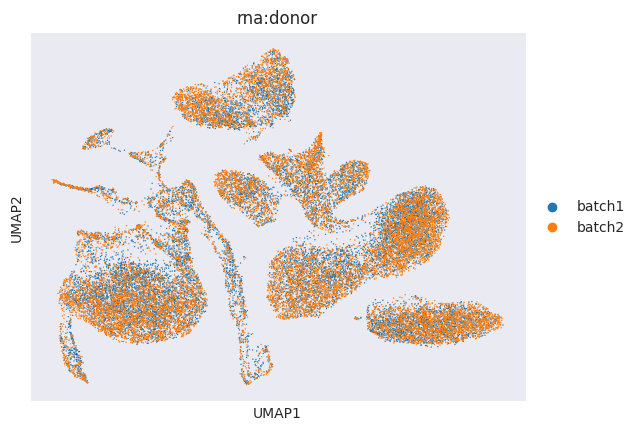

In [15]:
sc.pl.umap(model.adata, color=['rna:sample'], wspace=0.15, show=True)

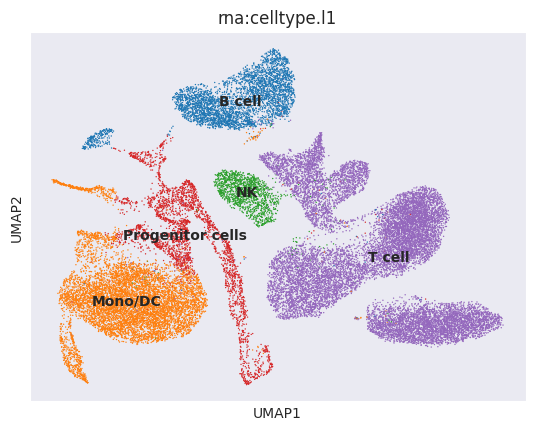

In [12]:
sc.pl.umap(model.adata, color=['rna:ct_highres'], wspace=0.15, show=True)

In [16]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

25

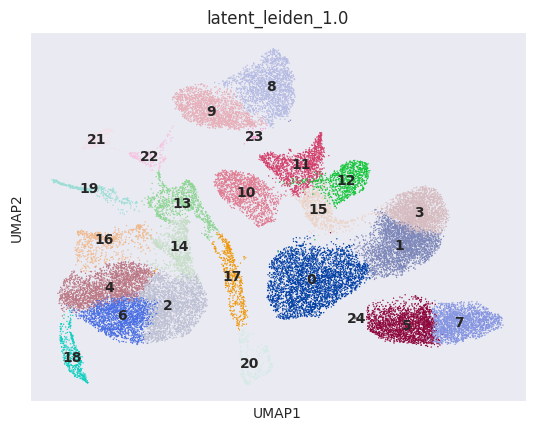

In [17]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [18]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/2_GSE128639/model/attr.pkl


In [19]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')